In [ ]:
# Importing
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.verbosity = 4
sc.settings.figdir = '../results/'

In [ ]:
adata = sc.datasets.pbmc3k()
print(adata)

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


In [ ]:
# Flag every mitrochondrial gene & calculate QC metrics
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

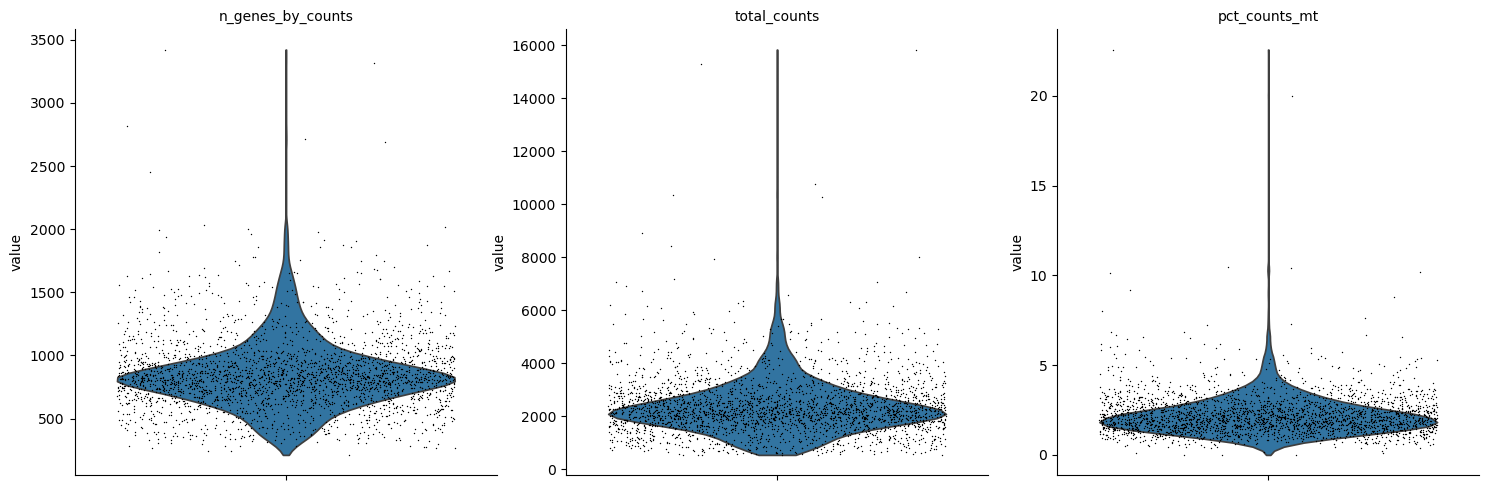

In [ ]:
# Visualize QC metrics
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True
)

#n_genes_by_counts: Number of genes expressed in each cell
#total_counts: Total number of counts (UMIs) in each cell
#pct_counts_mt: Percentage of counts that are mitochondrial

In [ ]:
# Keep only cells that have between 200 and 2500 genes, and less than 5% mitochondrial counts
adata = adata[adata.obs.n_genes_by_counts > 200]
adata = adata[adata.obs.n_genes_by_counts < 2500]
adata = adata[adata.obs.pct_counts_mt < 5]

# Filter genes that are expressed in less than 3 cells
sc.pp.filter_genes(adata, min_cells=3)
print(adata)

filtered out 19082 genes that are detected in less than 3 cells
AnnData object with n_obs × n_vars = 2638 × 13656
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'


c:\Users\billn\.conda\envs\scrna\lib\site-packages\scanpy\preprocessing\_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [ ]:
import os
os.makedirs('../data', exist_ok=True)

adata.write('../data/pbmc3k_qc.h5ad')